# Customs Transaction Risk Analysis

### An Explainable Data Analytics Approach for Risk-Based Customs Screening

**Author:** Asia Iddi Abdalah  
**Field:** Data Science & Artificial Intelligence  
**Focus:** Data Analytics

> **Project Note:** This is a methodological prototype developed using publicly available third-party trade data. It is not an operational customs control system and does not use confidential TRA/TANCIS data.

## 1. Problem Definition

Customs authorities process large volumes of import transactions, making it difficult to review every shipment in depth. A data-driven approach can help identify transactions that exhibit unusual valuation or statistical patterns and may therefore warrant further review.

This project develops a **customs transaction risk-analysis prototype** that uses historical shipment data to identify potentially unusual transactions and prioritize them for further audit review.

The analysis focuses on two broad areas of risk:

* **Valuation risk**  whether declared shipment values are consistent with contract values and market values observed within the same commodity group.
* **Statistical anomaly risk**  whether declared values exhibit patterns that may indicate unusual or fabricated reporting.

The objective is **not to determine whether a shipment involves tax evasion or fraud**, but to develop an explainable analytical approach for identifying transactions that may deserve closer examination.


## 2. Project Objective

The main objective of this analysis is to develop an explainable risk-scoring approach that combines multiple transaction-level indicators to classify shipments into **Low, Medium, and High risk categories**.

Specifically, the analysis aims to:

1. Examine the quality and structure of the customs transaction data.
2. Identify valuation and statistical indicators associated with potentially unusual transactions.
3. Combine these indicators into a weighted risk score.
4. Analyse the resulting risk categories and identify patterns across shipments and commodities.
5. Evaluate the limitations of the available data and identify areas where the approach could be extended with more complete customs information.


## 3. Data Source & Dataset Overview

### 3.1 Data Source

The analysis uses the **China-Africa Trade Monitoring dataset** obtained from Kaggle and filtered to transactions where **Tanzania is the import country**.

The dataset contains historical, third-party trade data and is **not sourced from TRA's internal TANCIS records**. Therefore, the analysis should be interpreted as a methodological prototype rather than an assessment of actual TRA customs transactions.

### 3.2 Dataset Overview

The filtered dataset contains **1,458 shipment records** across five commodity groups:

* Agricultural
* Electronics
* Machinery
* Minerals
* Textiles

The main variables used in the analysis include:

* `declared_value_usd` — declared value of the shipment
* `contract_value_usd` — contract value recorded for the shipment
* `market_price_per_unit` — market price per unit
* `quantity` — quantity associated with the shipment
* `commodity` — commodity category

Additional derived variables are used later in the analysis to represent valuation deviations, statistical anomalies, risk scores, and risk categories.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
df = pd.read_csv("naot_risk_output.csv")

df.head()

,shipment_id,commodity,hs_code,declared_value_usd,contract_value_usd,market_price_per_unit,declared_vs_market_ratio,declared_vs_contract_ratio,market_outlier_flag,contract_deviation_flag,benford_rare_digit_flag,is_round_value,risk_score,risk_category,risk_reasons
0,SHP02609,Agricultural,260300,8567,7570,413.49,0.01,1.13,False,True,True,False,55,High,Declared value deviates from contract value; V...
1,SHP00439,Agricultural,843890,9017,8055,"2,633.02",0.00,1.12,False,True,True,False,55,High,Declared value deviates from contract value; V...
2,SHP06476,Agricultural,843890,87823,88747,83.60,1.15,0.99,True,False,True,False,50,High,Unusual price vs peer commodities; Value patte...
3,SHP04376,Minerals,843890,81732,81398,353.26,3.92,1.00,True,False,True,False,50,High,Unusual price vs peer commodities; Value patte...
4,SHP03442,Agricultural,520942,97198,96512,82.49,1.24,1.01,True,False,True,False,50,High,Unusual price vs peer commodities; Value patte...


In [4]:
df.shape

(1458, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   shipment_id                 1458 non-null   object 
 1   commodity                   1458 non-null   object 
 2   hs_code                     1458 non-null   int64  
 3   declared_value_usd          1458 non-null   int64  
 4   contract_value_usd          1458 non-null   int64  
 5   market_price_per_unit       1458 non-null   float64
 6   declared_vs_market_ratio    1458 non-null   float64
 7   declared_vs_contract_ratio  1458 non-null   float64
 8   market_outlier_flag         1458 non-null   bool   
 9   contract_deviation_flag     1458 non-null   bool   
 10  benford_rare_digit_flag     1458 non-null   bool   
 11  is_round_value              1458 non-null   bool   
 12  risk_score                  1458 non-null   int64  
 13  risk_category               1458 

In [6]:
df.columns.tolist()

['shipment_id',
 'commodity',
 'hs_code',
 'declared_value_usd',
 'contract_value_usd',
 'market_price_per_unit',
 'declared_vs_market_ratio',
 'declared_vs_contract_ratio',
 'market_outlier_flag',
 'contract_deviation_flag',
 'benford_rare_digit_flag',
 'is_round_value',
 'risk_score',
 'risk_category',
 'risk_reasons']

In [7]:
# Check for missing values and duplicate shipments
print("Missing values:", df.isnull().sum().sum())
print("Duplicate shipment IDs:", df["shipment_id"].duplicated().sum())

Missing values: 0
Duplicate shipment IDs: 0


In [8]:
# Basic descriptive statistics
df.describe()

,hs_code,declared_value_usd,contract_value_usd,market_price_per_unit,declared_vs_market_ratio,declared_vs_contract_ratio,risk_score
count,"1,458.00","1,458.00","1,458.00","1,458.00","1,458.00","1,458.00","1,458.00"
mean,"510,216.25","78,468.89","78,480.13","1,460.20",0.13,1.00,4.16
std,"301,280.10","41,257.23","41,266.34",863.13,0.69,0.02,9.06
min,"100,610.00","5,078.00","4,891.00",5.63,0.00,0.86,0.00
25%,"260,300.00","44,218.25","44,467.00",730.97,0.01,0.99,0.00
50%,"520,942.00","79,324.00","79,178.50","1,407.43",0.03,1.00,0.00
75%,"843,890.00","113,461.25","113,695.50","2,199.74",0.07,1.01,0.00
max,"847,130.00","149,925.00","150,535.00","2,998.80",21.98,1.13,55.00


In [9]:
risk_indicators = [
    "contract_deviation_flag",
    "market_outlier_flag",
    "benford_rare_digit_flag",
    "is_round_value"
]

df[risk_indicators].sum().sort_values(ascending=False)

benford_rare_digit_flag    232
market_outlier_flag         41
contract_deviation_flag      5
is_round_value               1
dtype: int64

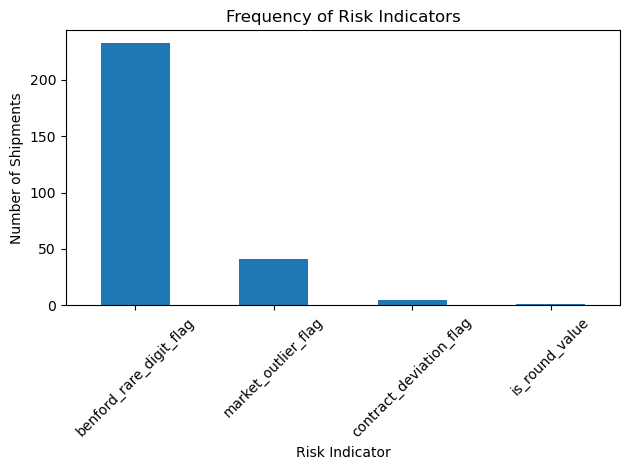

In [22]:
indicator_counts = df[risk_indicators].sum().sort_values(ascending=False)

indicator_counts.plot(kind="bar")

plt.title("Frequency of Risk Indicators")
plt.ylabel("Number of Shipments")
plt.xlabel("Risk Indicator")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Risk Indicator Analysis

Four transaction-level indicators were used to identify potentially unusual shipments:

- **Contract deviation**   identifies shipments where the declared value differs substantially from the contract value.
- **Market outlier**   identifies shipments whose values are unusually different from other shipments within the same commodity group.
- **Benford rare digit**   identifies unusual first-digit patterns in declared values.
- **Round-number bias**   identifies unusually round declared values.

These indicators are treated as risk signals rather than evidence of fraud or tax evasion. A shipment flagged by an indicator should therefore be considered for further review rather than automatically classified as non-compliant.

In [13]:
risk_distribution = df["risk_category"].value_counts()

risk_distribution

risk_category
Low       1186
Medium     262
High        10
Name: count, dtype: int64

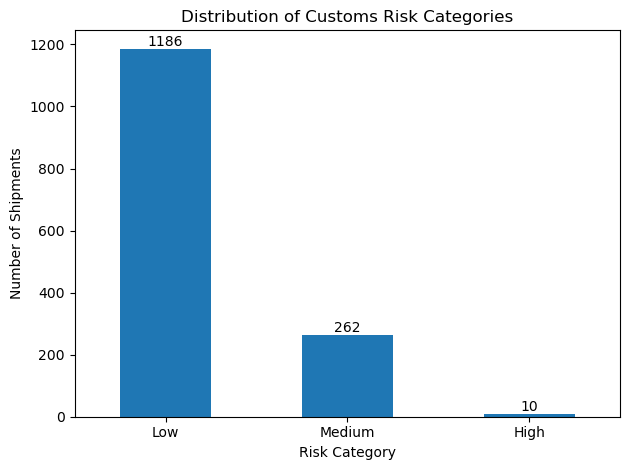

In [20]:
risk_distribution = df["risk_category"].value_counts()

ax = risk_distribution.plot(kind="bar")

plt.title("Distribution of Customs Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 6. Risk Score and Risk Categories

The identified risk indicators are combined into a weighted risk score. Higher scores indicate that a shipment triggered more significant risk indicators.

The scoring system assigns:

- Contract deviation: 35 points
- Market outlier: 30 points
- Benford rare digit: 20 points
- Round-number bias: 15 points

Shipments are then classified into Low, Medium, and High risk categories based on their total scores.

In [15]:
high_risk = df[df["risk_category"] == "High"].copy()

high_risk[
    [
        "shipment_id",
        "commodity",
        "declared_value_usd",
        "contract_value_usd",
        "risk_score",
        "risk_reasons"
    ]
].sort_values("risk_score", ascending=False)

,shipment_id,commodity,declared_value_usd,contract_value_usd,risk_score,risk_reasons
0,SHP02609,Agricultural,8567,7570,55,Declared value deviates from contract value; V...
1,SHP00439,Agricultural,9017,8055,55,Declared value deviates from contract value; V...
2,SHP06476,Agricultural,87823,88747,50,Unusual price vs peer commodities; Value patte...
3,SHP04376,Minerals,81732,81398,50,Unusual price vs peer commodities; Value patte...
4,SHP03442,Agricultural,97198,96512,50,Unusual price vs peer commodities; Value patte...
5,SHP09303,Electronics,96405,97055,50,Unusual price vs peer commodities; Value patte...
6,SHP07351,Electronics,94934,93990,50,Unusual price vs peer commodities; Value patte...
7,SHP03246,Electronics,5860,5172,35,Declared value deviates from contract value
8,SHP08545,Electronics,6884,6141,35,Declared value deviates from contract value
9,SHP02103,Minerals,5925,6910,35,Declared value deviates from contract value


In [16]:
high_risk["commodity"].value_counts()

commodity
Agricultural    4
Electronics     4
Minerals        2
Name: count, dtype: int64

In [17]:
high_risk[risk_indicators].sum().sort_values(ascending=False)

benford_rare_digit_flag    7
contract_deviation_flag    5
market_outlier_flag        5
is_round_value             0
dtype: int64

## 8. Key Findings

The analysis produced several important findings:

1. The majority of shipments were classified as Low Risk, with 1,186 shipments (81.3%), while 262 (18.0%) were classified as Medium Risk and only 10 (0.7%) as High Risk.

2. The Benford rare-digit indicator was the most frequently triggered indicator overall, followed by the market outlier indicator. Contract deviation and round-number bias were comparatively less frequent.

3. Among the 10 High-Risk shipments, Agricultural and Electronics shipments accounted for four each, while Minerals accounted for two.

4. Seven of the High-Risk shipments triggered the Benford rare-digit indicator, while five triggered contract deviation and five were identified as market outliers. No High-Risk shipment was flagged for round-number bias.

5. The results demonstrate how multiple transaction-level indicators can be combined to prioritize a relatively small number of shipments for further review.

## 9. Limitations

This analysis has several limitations:

- The dataset is a public third-party Kaggle dataset rather than TRA's internal TANCIS data.
- HS-code classification and transport-route consistency checks were excluded because the available data did not provide sufficient reliable information for these indicators.
- The market-price analysis uses relative differences within commodity groups because the available market-price variable was not directly comparable with declared shipment values.
- The dataset does not contain transaction dates, limiting the ability to analyse changes and patterns over time.
- The risk indicators should be interpreted as screening signals and not as evidence of fraud, tax evasion, or non-compliance.
- The risk scoring weights are prototype assumptions and would require validation and calibration using real customs audit outcomes.

## 10. Conclusion

This project developed an explainable customs transaction risk-analysis prototype using historical trade data from Tanzania.

By combining valuation and statistical indicators into a weighted risk score, the analysis was able to classify shipments according to their relative risk and identify a small group of transactions requiring closer attention.

The prototype demonstrates how data analytics can support risk-based customs auditing by helping prioritize transactions for further investigation rather than relying only on manual or random selection.

With access to real customs data, tariff information, historical audit outcomes, and transaction dates, the approach could be further validated and extended.